In [2]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib as plt

#1. caricare il dataset
iris = load_iris()
X = iris.data
y = iris.target

#2. Suddividere il dataset in training e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

#3. Standardizzare le feauture (passaggio cruciale per la KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)    #usare la media/std del training set

#4. Trovare il K ottimale usando Cross-Validation (sul training set)
k_range = range(1,26) # proviamo K da 1 a 25
k_scores = []

print("Ricerca del K ottimle tramite Cross-Validation")
for k in k_range:
    # Per la CV non è necessario scalare i dati separatamente, ma lo facciamo qui per semplicità
    # Una Pipeline sarebbe la soluzione più corretta
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    # esegui CV a 10-fold
    scores = cross_val_score(knn_cv, X_train_scaled, y_train,cv=10, scoring = 'accuracy')
    k_scores.append(scores.mean())

# Trova il K che ha dato l'accuracy media più alta
optimal_k = k_range[np.argmax(k_scores)]
print(f"Il valore ottimale di K è: {optimal_k}\n")

# Opzionale grafico per visualizzare l'errore al variare di K
# plt.plot(k_range, [1-score for score in k_scores])
# plt.xlabel('Valore di k')
# plt.ylabel('Tasso di errore (1-Accuracy)')
# plt.title('Elbow Method per KNN')
# plt.show()

# 5. Addestrare il modello finale con K ottimale (su tutti i tipi di training)
# Usiamo anche la variante "pesata" (weights = 'distance')
model = KNeighborsClassifier(n_neighbors=optimal_k, weights='distance', metric='euclidean')

# "Addestramento" (solo memorizzazione)
model.fit(X_train_scaled, y_train)

# 6. Valutare il modello sul test set (scalato!)
y_pred = model.predict(X_test_scaled)

# 7. Valutazione
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy sul Test set (K={optimal_k}, wighted): {accuracy:.4f}")
print("\nReport di Classificazione:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Ricerca del K ottimle tramite Cross-Validation
Il valore ottimale di K è: 14

Accuracy sul Test set (K=14, wighted): 1.0000

Report di Classificazione:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



Variante metodo di Elbow

Matplotlib is building the font cache; this may take a moment.


Avvio ricerca K ottimale tramite Cross-Validation (cv=10)
ricerca Completata.
L'accuratezza massima media è stata:  0.9445
Il valore ottimale di K è: 14


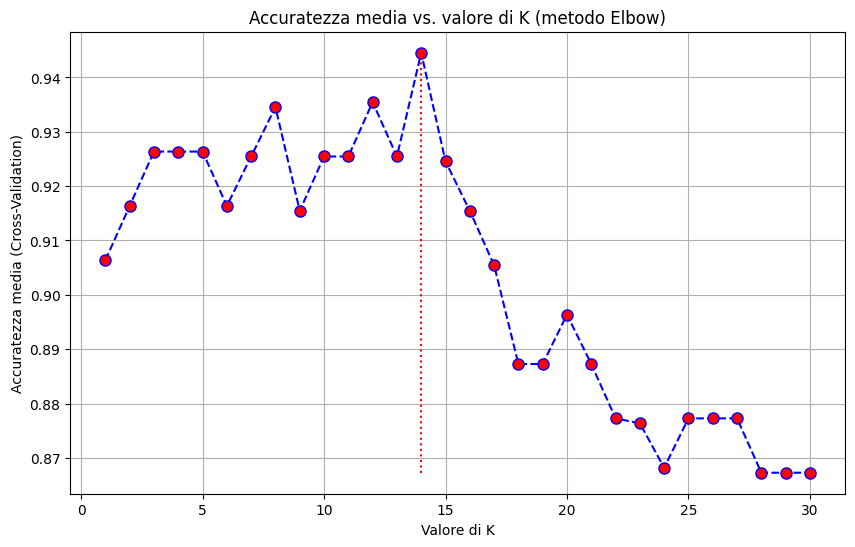

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# -- 1. Caricamento e Preparazione dei Dati ---
iris = load_iris()
X = iris.data
y = iris.target

# Dividiamo i dati in training (70%) e test (30%)
# La ricerca di K si fa SOLO su training set!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardizziamo le feature (Fondamentale per KNN)
# Adattiamo lo scaler sul SOLO training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Trasformiamo il test set con i parametri (media,std) del training set
X_test_scaled = scaler.transform(X_test)

# --- 2. Ricerca del K Ottimale tramite Cross-Validation --

# Definiamo un intervallo di K da testare (es. da 1 a 30)
k_range = range(1,31)
k_scores = []   # Lista per salvare l'accuratezza media per ogni K

print("Avvio ricerca K ottimale tramite Cross-Validation (cv=10)")

# Iteriamo su ogni valore di K
for k in k_range:
    # Inizializzaziamo il classificatore KNN con il k corrente
    knn = KNeighborsClassifier(n_neighbors=k)

    # Eseguiamo la validazione incrociata a 10 fold
    # 'cv=10' divide X_train_scaled in 10 parti: 9 per addestare, 1 per validare e ripete
    # " 'scoring='accuracy' " ci dice di misurare l'accuratezza
    # 'scores' sarà un array di 10 valori (l'accuratezza di ogni fold)
    scores = cross_val_score(knn, X_train_scaled, y_train,cv=10, scoring = 'accuracy')

    # calcoliamo l'accuratezza media di tutti i 10 fold e la salviamo
    k_scores.append(scores.mean())

# Trova il valore di K che ha dato l'accuratezza media più alta
optimal_k_index = np.argmax(k_scores)
optimal_k = k_range[optimal_k_index]

print(f"ricerca Completata.")
print(f"L'accuratezza massima media è stata: {k_scores[optimal_k_index]: .4f}")
print(f"Il valore ottimale di K è: {optimal_k}")

# --- 3 (opzionale) Plot dei risulati ("Metodo "Elbow") ---

plt.figure(figsize = (10,6))
plt.plot(k_range, k_scores, color = 'blue', linestyle = 'dashed', marker = 'o', markerfacecolor = 'red', markersize = 8)
plt.title('Accuratezza media vs. valore di K (metodo Elbow)')
plt.xlabel('Valore di K')
plt.ylabel('Accuratezza media (Cross-Validation)')
plt.grid(True)
#Evidenzia il punto ottimale
plt.vlines(optimal_k, ymin=min(k_scores), ymax=max(k_scores), colors='red', linestyles='dotted')
plt.show()